In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc

In [2]:
columns = [
'id','diagnosis',
'radius_mean','texture_mean','perimeter_mean','area_mean','smoothness_mean',
'compactness_mean','concavity_mean','concave_points_mean','symmetry_mean','fractal_dimension_mean',

'radius_se','texture_se','perimeter_se','area_se','smoothness_se',
'compactness_se','concavity_se','concave_points_se','symmetry_se','fractal_dimension_se',

'radius_worst','texture_worst','perimeter_worst','area_worst','smoothness_worst',
'compactness_worst','concavity_worst','concave_points_worst','symmetry_worst','fractal_dimension_worst'
]

df = pd.read_csv("dataset/wdbc.data", names=columns)

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
df.shape

(569, 32)

In [7]:
df = df.drop(columns=["id"])
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [9]:
df['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [4]:
df['diagnosis'] = df['diagnosis'].map({'M':1, 'B':0})
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
X = df.drop('diagnosis',axis=1)
y = df['diagnosis']

print(X.shape)
print(y.shape)

(569, 31)
(569,)


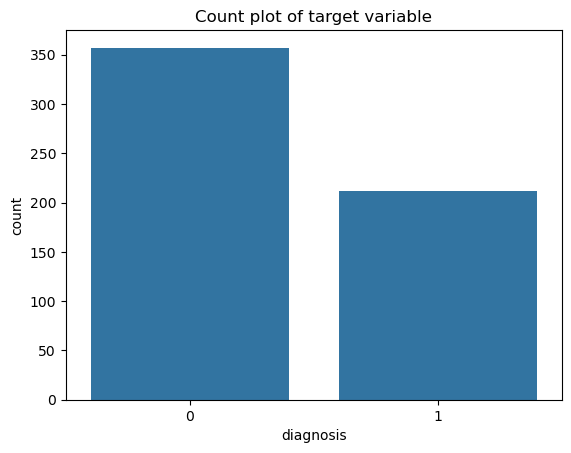

In [15]:
plt.figure()
sns.countplot(x=y)
plt.title("Count plot of target variable")
plt.savefig("Count plot of target variable")
plt.show()

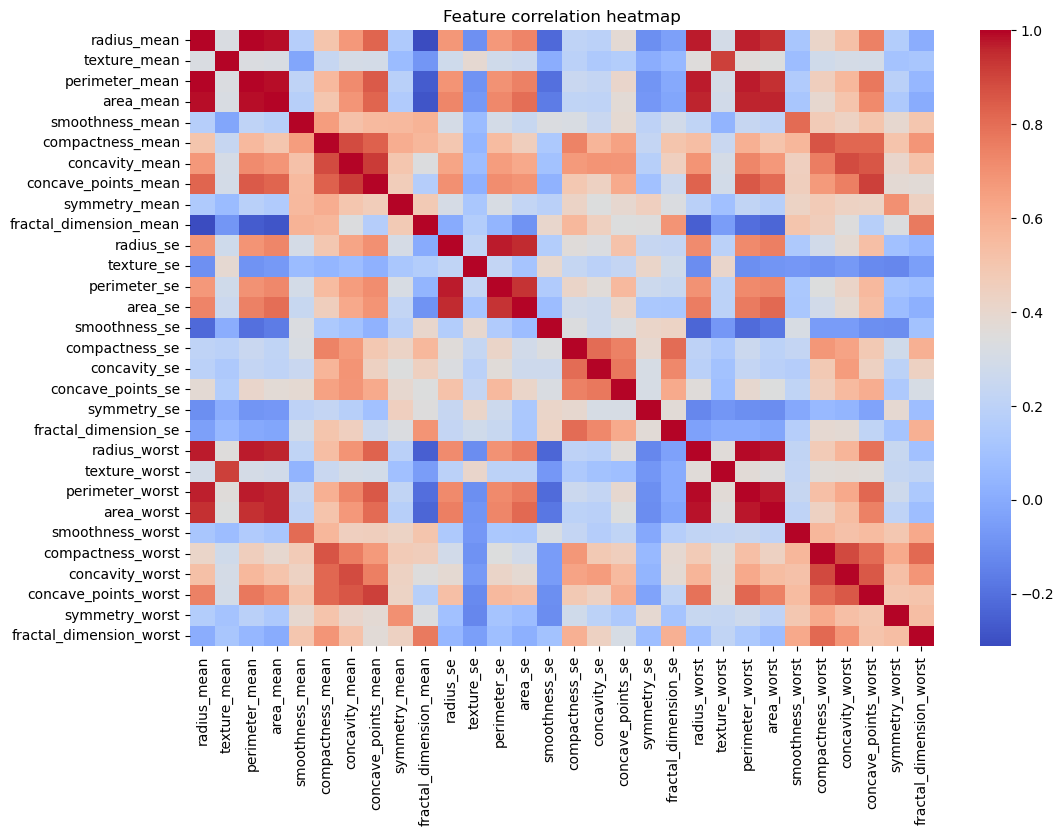

In [18]:
plt.figure(figsize=(12,8))
corr = X.corr()
sns.heatmap(corr, cmap="coolwarm")
plt.title("Feature correlation heatmap")
plt.savefig("Feature Correlation heatmap")
plt.show()

The correlation heatmap shows strong correlations among several features such as radius, perimeter, and area measurements. This indicates that some features contain similar information derived from tumor geometry.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(455, 31)
(114, 31)


In [28]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train,y_train)
y_pred_dt = dt_model.predict(X_test)

accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test,y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)

print("Decision tree Accuracy: ", accuracy_dt)
print("Decision tree Precision: ", precision_dt)
print("Decision tree Recall: ", recall_dt)

print(classification_report(y_test, y_pred_dt))

Decision tree Accuracy:  0.9473684210526315
Decision tree Precision:  0.9302325581395349
Decision tree Recall:  0.9302325581395349
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        71
           1       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



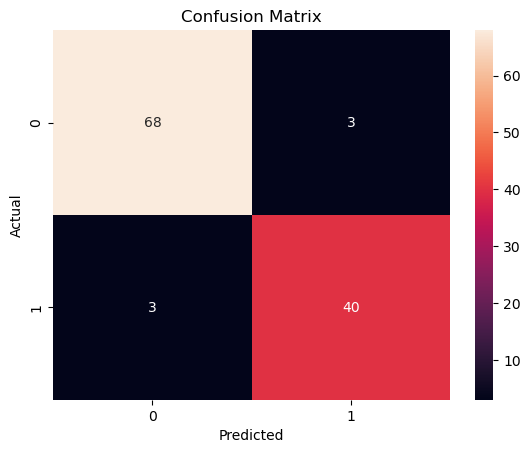

In [29]:
cm = confusion_matrix(y_test, y_pred_dt)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("Confusion Matrix")
plt.show()

In [19]:
# Hyper-parameter tuning
criterions = ['gini', 'entropy']
max_depths = [3, 5, 7, None]
min_splits = [2, 5]
min_leafs = [1, 2]

result = []
for criteria in criterions:
    for depth in max_depths:
        for split in min_splits:
            for leafs in min_leafs:
                model = DecisionTreeClassifier(
                        criterion = criteria,
                        max_depth = depth,
                        min_samples_split = split,
                        min_samples_leaf = leafs,
                        random_state = 42)
                scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')

                result.append([criteria,
                                depth,
                                split,
                                leafs,
                                scores.mean()])

                

In [26]:
results_df = pd.DataFrame(result, columns=[
    'Criterion',
    'Max Depth',
    'Min Samples Split',
    'Min Samples Leaf',
    'Avg CV Accuracy'
])

results_df

,Criterion,Max Depth,Min Samples Split,Min Samples Leaf,Avg CV Accuracy
0,gini,3.0,2,1,0.927473
1,gini,3.0,2,2,0.927473
2,gini,3.0,5,1,0.927473
3,gini,3.0,5,2,0.927473
4,gini,5.0,2,1,0.925275
5,gini,5.0,2,2,0.931868
6,gini,5.0,5,1,0.934066
7,gini,5.0,5,2,0.931868
8,gini,7.0,2,1,0.916484
9,gini,7.0,2,2,0.918681


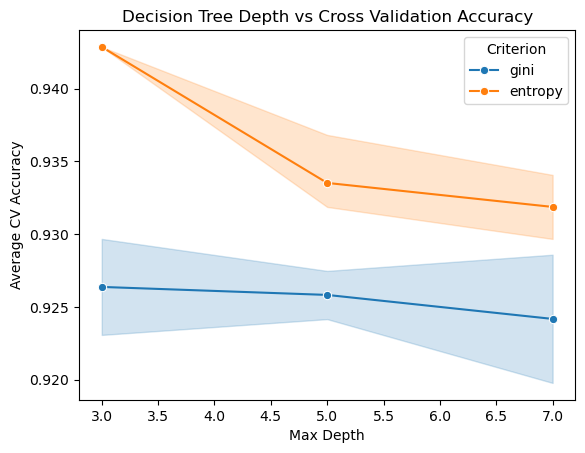

In [46]:
plt.figure()

sns.lineplot(data=results_df, x="Max Depth", y="Avg CV Accuracy", hue="Criterion", marker="o")

plt.title("Decision Tree Depth vs Cross Validation Accuracy")
plt.xlabel("Max Depth")
plt.ylabel("Average CV Accuracy")
plt.savefig("Decision Tree Depth vs Cross Validation Accuracy")

plt.show()

In [27]:
best_row = results_df.loc[results_df['Avg CV Accuracy'].idxmax()]

best_row

Criterion             entropy
Max Depth                 5.0
Min Samples Split           2
Min Samples Leaf            1
Avg CV Accuracy      0.947253
Name: 20, dtype: object

In [28]:
best_dt = DecisionTreeClassifier(
    criterion=best_row['Criterion'],
    max_depth=int(best_row['Max Depth']),
    min_samples_split=int(best_row['Min Samples Split']),
    min_samples_leaf=int(best_row['Min Samples Leaf']),
    random_state=42
)

best_dt.fit(X_train, y_train)

y_pred_best_dt = best_dt.predict(X_test)

print("Tuned Decision Tree Accuracy:", accuracy_score(y_test, y_pred_best_dt))

Tuned Decision Tree Accuracy: 0.956140350877193


In [10]:
# for report 
criterions = ['gini', 'entropy']
max_depths = [3, 5, 7, None]

result = []
for criteria in criterions:
    for depth in max_depths:
        model = DecisionTreeClassifier(
                criterion = criteria,
                max_depth = depth,
                random_state = 42)
        scores_acc = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
        scores_f1 = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')

        result.append([criteria, depth, scores_acc.mean(),scores_f1.mean()])

df = pd.DataFrame(result, columns=['Criterion', 'Max Depth', 'Accuracy', 'F1 Score'])

# convert to float and round
df['Accuracy'] = df['Accuracy'].astype(float).round(4)
df['F1 Score'] = df['F1 Score'].astype(float).round(4)

print(df)

  Criterion  Max Depth  Accuracy  F1 Score
0      gini        3.0    0.9275    0.9007
1      gini        5.0    0.9253    0.8987
2      gini        7.0    0.9165    0.8878
3      gini        NaN    0.9165    0.8878
4   entropy        3.0    0.9341    0.9111
5   entropy        5.0    0.9473    0.9282
6   entropy        7.0    0.9341    0.9126
7   entropy        NaN    0.9341    0.9126


In [30]:
cv_score_dt = cross_val_score(best_dt,X_train,y_train,cv=5,scoring='accuracy')

print("Accuracy for each fold:")
for i, score in enumerate(cv_score_dt, 1):
    print(f"Fold {i}: {score:.4f} ({score*100:.2f}%)")

Accuracy for each fold:
Fold 1: 0.9560 (95.60%)
Fold 2: 0.9121 (91.21%)
Fold 3: 0.9780 (97.80%)
Fold 4: 0.9451 (94.51%)
Fold 5: 0.9451 (94.51%)


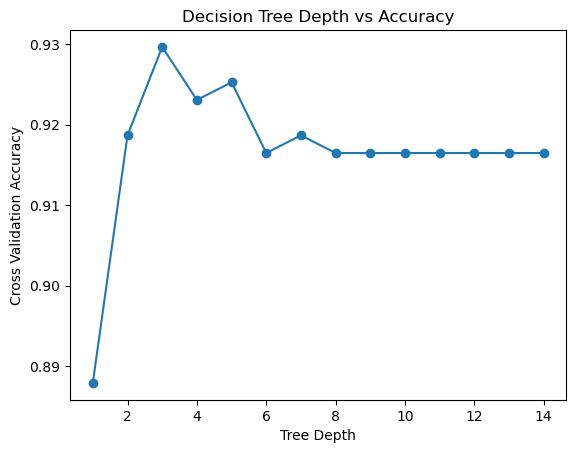

In [47]:
depth_scores = []

for depth in range(1, 15):

    model = DecisionTreeClassifier(max_depth=depth, random_state=42)

    scores = cross_val_score(model, X_train, y_train, cv=5)

    depth_scores.append(scores.mean())

plt.plot(range(1,15), depth_scores, marker='o')

plt.xlabel("Tree Depth")
plt.ylabel("Cross Validation Accuracy")
plt.title("Decision Tree Depth vs Accuracy")
plt.savefig("Decision Tree Depth vs Accuracy")
plt.show()

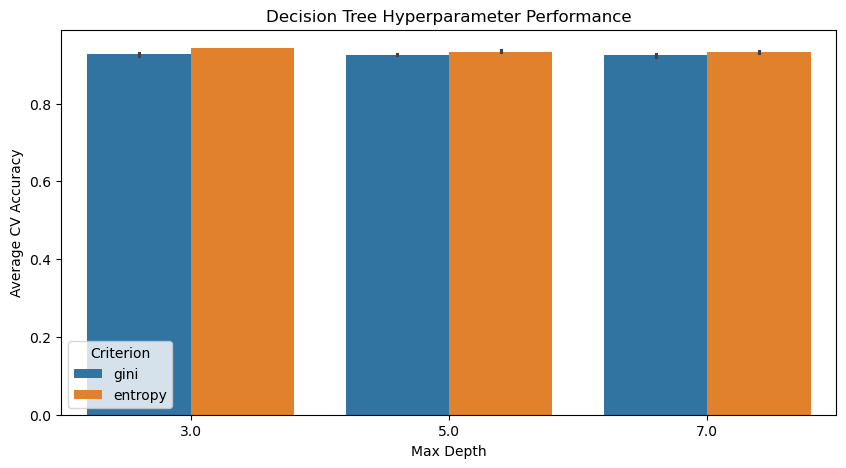

In [48]:
plt.figure(figsize=(10,5))

sns.barplot(data=results_df, x="Max Depth", y="Avg CV Accuracy", hue="Criterion")

plt.title("Decision Tree Hyperparameter Performance")
plt.xlabel("Max Depth")
plt.ylabel("Average CV Accuracy")
plt.savefig("Decision Tree Hyperparameter Performance")
plt.show()

In [49]:
results_df.sort_values(by="Avg CV Accuracy", ascending=False).head(10)

,Criterion,Max Depth,Min Samples Split,Min Samples Leaf,Avg CV Accuracy
19,entropy,3.0,5,2,0.942857
18,entropy,3.0,5,1,0.942857
17,entropy,3.0,2,2,0.942857
16,entropy,3.0,2,1,0.942857
20,entropy,5.0,2,1,0.938462
24,entropy,7.0,2,1,0.934066
29,entropy,NaN,2,2,0.934066
25,entropy,7.0,2,2,0.934066
28,entropy,NaN,2,1,0.934066
22,entropy,5.0,5,1,0.931868


In [50]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [51]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9649122807017544
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



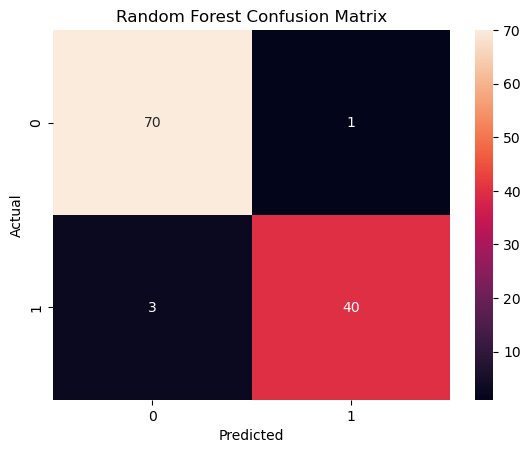

In [53]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure()

sns.heatmap(cm_rf, annot=True, fmt='d')

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("Random Forest Confusion Matrix")
plt.show()

In [12]:
n_estimators_list = [50, 100, 150]
max_depth_list = [5, 10, None]
max_features_list = ['sqrt', 'log2']
bootstrap_list = [True, False]

In [14]:
rf_results = []

for n in n_estimators_list:
    for depth in max_depth_list:
        for features in max_features_list:
                model = RandomForestClassifier(
                    n_estimators=n,
                    max_depth=depth,
                    max_features=features,
                    random_state=42
                )

                scores_acc = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
                scores_f1 = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
                rf_results.append([
                    n,
                    depth,
                    features,
                    scores_acc.mean(),
                    scores_f1.mean()
                ])

In [15]:
rf_results_df = pd.DataFrame(rf_results, columns=[
    'n_estimators',
    'Max Depth',
    'Max Features',
    'Avg CV Accuracy',
    'Avg CV F1 score'
])

rf_results_df

,n_estimators,Max Depth,Max Features,Avg CV Accuracy,Avg CV F1 score
0,50,5.0,sqrt,0.951648,0.932726
1,50,5.0,log2,0.949451,0.930383
2,50,10.0,sqrt,0.953846,0.936470
3,50,10.0,log2,0.947253,0.927503
4,50,NaN,sqrt,0.953846,0.936470
5,50,NaN,log2,0.947253,0.927503
6,100,5.0,sqrt,0.949451,0.929841
7,100,5.0,log2,0.951648,0.933461
8,100,10.0,sqrt,0.953846,0.935995
9,100,10.0,log2,0.949451,0.930944


In [21]:
best_rf_row = rf_results_df.loc[rf_results_df['Avg CV Accuracy'].idxmax()]

best_rf_row

n_estimators             50
Max Depth              10.0
Max Features           sqrt
Avg CV Accuracy    0.953846
Avg CV F1 score     0.93647
Name: 2, dtype: object

In [22]:
best_rf = RandomForestClassifier(
    n_estimators=int(best_rf_row['n_estimators']),
    max_depth=None if pd.isna(best_rf_row['Max Depth']) else int(best_rf_row['Max Depth']),
    max_features=best_rf_row['Max Features'],
    random_state=42
)

best_rf.fit(X_train, y_train)

y_pred_best_rf = best_rf.predict(X_test)

print("Tuned Random Forest Accuracy:", accuracy_score(y_test, y_pred_best_rf))

Tuned Random Forest Accuracy: 0.9649122807017544


In [24]:
# for report

cv_scores = cross_val_score(best_rf,X_train,y_train,cv=5,scoring='accuracy')

print("Accuracy for each fold:")
for i, score in enumerate(cv_scores, 1):
    print(f"Fold {i}: {score:.4f} ({score*100:.2f}%)")

Accuracy for each fold:
Fold 1: 0.9560 (95.60%)
Fold 2: 0.9451 (94.51%)
Fold 3: 0.9780 (97.80%)
Fold 4: 0.9451 (94.51%)
Fold 5: 0.9451 (94.51%)


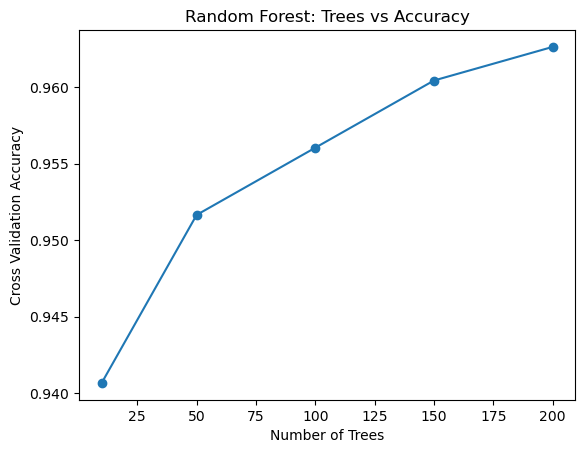

In [60]:
tree_scores = []

for n in [10, 50, 100, 150, 200]:

    model = RandomForestClassifier(n_estimators=n, random_state=42)

    scores = cross_val_score(model, X_train, y_train, cv=5)

    tree_scores.append(scores.mean())

plt.plot([10,50,100,150,200], tree_scores, marker='o')

plt.title("Random Forest: Trees vs Accuracy")
plt.xlabel("Number of Trees")
plt.ylabel("Cross Validation Accuracy")
plt.savefig("Random Forest: Trees vs Accuracy")
plt.show()

In [61]:
dt_cv_scores = cross_val_score(best_dt, X, y, cv=5, scoring='accuracy')

print("Decision Tree Fold Accuracies:", dt_cv_scores)
print("Decision Tree Average Accuracy:", dt_cv_scores.mean())

Decision Tree Fold Accuracies: [0.90350877 0.9122807  0.95614035 0.93859649 0.95575221]
Decision Tree Average Accuracy: 0.9332557056357709


In [62]:
rf_cv_scores = cross_val_score(best_rf, X, y, cv=5, scoring='accuracy')

print("Random Forest Fold Accuracies:", rf_cv_scores)
print("Random Forest Average Accuracy:", rf_cv_scores.mean())

Random Forest Fold Accuracies: [0.94736842 0.93859649 0.97368421 0.97368421 0.97345133]
Random Forest Average Accuracy: 0.9613569321533924


In [63]:
comparison_table = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Fold 1": [dt_cv_scores[0], rf_cv_scores[0]],
    "Fold 2": [dt_cv_scores[1], rf_cv_scores[1]],
    "Fold 3": [dt_cv_scores[2], rf_cv_scores[2]],
    "Fold 4": [dt_cv_scores[3], rf_cv_scores[3]],
    "Fold 5": [dt_cv_scores[4], rf_cv_scores[4]],
    "Average Accuracy": [dt_cv_scores.mean(), rf_cv_scores.mean()]
})

comparison_table

,Model,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Average Accuracy
0,Decision Tree,0.903509,0.912281,0.956140,0.938596,0.955752,0.933256
1,Random Forest,0.947368,0.938596,0.973684,0.973684,0.973451,0.961357


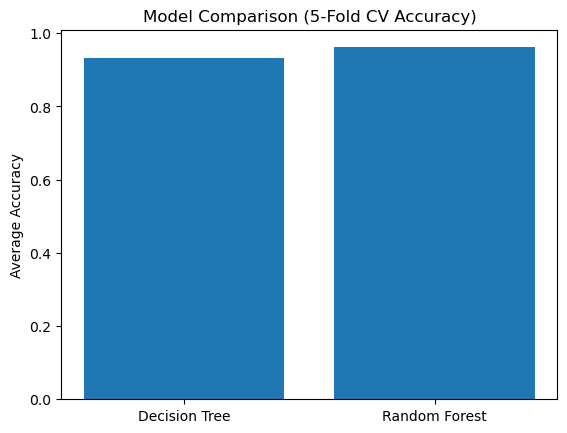

In [67]:
plt.figure()

models = ["Decision Tree", "Random Forest"]
scores = [dt_cv_scores.mean(), rf_cv_scores.mean()]

plt.bar(models, scores)

plt.title("Model Comparison (5-Fold CV Accuracy)")
plt.ylabel("Average Accuracy")
plt.savefig("Model Comparison (5-Fold CV Accuracy)")
plt.show()

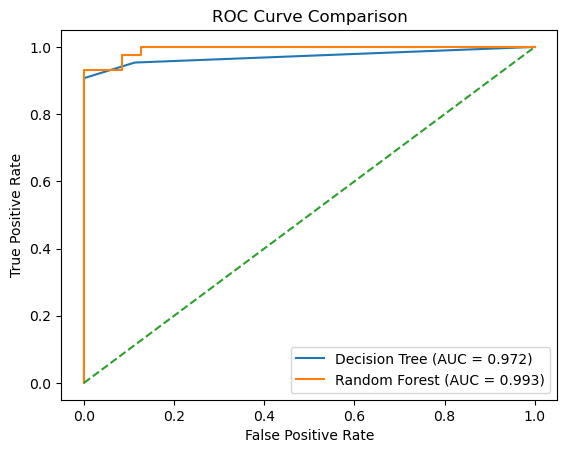

In [65]:
# probabilities for ROC
dt_probs = best_dt.predict_proba(X_test)[:,1]
rf_probs = best_rf.predict_proba(X_test)[:,1]

# ROC values
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

# AUC scores
dt_auc = auc(dt_fpr, dt_tpr)
rf_auc = auc(rf_fpr, rf_tpr)

plt.figure()

plt.plot(dt_fpr, dt_tpr, label=f"Decision Tree (AUC = {dt_auc:.3f})")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_auc:.3f})")

plt.plot([0,1],[0,1], linestyle="--")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

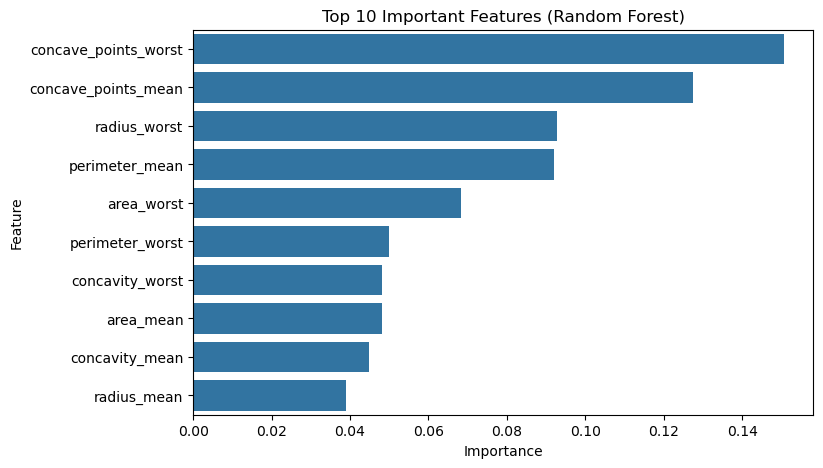

In [66]:
importances = best_rf.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

top_features = importance_df.head(10)

plt.figure(figsize=(8,5))

sns.barplot(data=top_features, x="Importance", y="Feature")

plt.title("Top 10 Important Features (Random Forest)")
plt.savefig("Top 10 Important Features (Random Forest)")

plt.show()